# Topic Modeling of U.S. Earnings Call Transcripts (2025–2026)

## Research Question

Earnings calls are a **ritualized genre of corporate communication**: a quarterly ritual in which company executives narrate financial performance to an audience of sell-side analysts. Unlike unstructured corporate speech, these calls follow a predictable script (prepared remarks → Q&A) and are subject to legal and regulatory constraints (forward-looking statement disclaimers, Regulation FD). This ritual structure makes them ideal for computational text analysis: the genre is stable enough to make cross-document comparisons meaningful, but the *content* varies across companies, sectors, and time.

**Central hypothesis:** Although earnings calls are a uniform genre, the topical structure of their content is not random. We expect to find:
1. A set of recurring **latent topics** that structure corporate financial discourse (e.g., growth strategy, cost management, macroeconomic risk)
2. **Temporal variation** in topic prominence, reflecting the Q4/Q3 reporting cycle and macro events
3. **Distinct topical footprints** for executive speech (forward-looking, strategic) vs. analyst questions (probing, sector-specific)

## Method

We apply **Latent Dirichlet Allocation (LDA)**, a generative probabilistic model that assumes each document is a mixture of latent topics, and each topic is a distribution over words (Blei, Ng & Jordan 2003). LDA is well-suited to earnings calls because:
- Documents are long enough (median ~800 words) to support stable topic estimates
- The genre's vocabulary is domain-specific but consistent, making unsupervised discovery tractable
- Topic proportions per document can be linked back to metadata (date, speaker role) for downstream analysis

The document-topic distribution matrix (γ) and topic-term matrix (β) are exported for visualization in R.

---
*Corpus: ~2,900 earnings call transcripts from investing.com, spanning September 2025 – March 2026.*  
*Pipeline: R (corpus preparation) → Python/gensim (LDA) → R/ggplot2 (visualization)*

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Topic modeling
from gensim import corpora, models
from gensim.models import CoherenceModel

# Download required NLTK data (only runs if not yet downloaded)
for resource in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if 'punkt' in resource else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

print(f"pandas {pd.__version__}, numpy {np.__version__}")
print("Setup complete.")

pandas 2.3.3, numpy 1.26.4
Setup complete.


[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>
[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify
[nltk_data]     failed: unable to get local issuer certificate
[nltk_data]     (_ssl.c:997)>


## 1. Loading and Describing the Corpus

The corpus was assembled from ~2,969 individual transcript RDS files using `00_prepare_corpus.R`. Each row in the CSV corresponds to one earnings call transcript, with the full text of all speakers (excluding the call operator) concatenated into a single document.

In [2]:
# Load the document-level corpus prepared by 00_prepare_corpus.R
docs = pd.read_csv('data/corpus_documents.csv', parse_dates=['call_date', 'call_month'])

print(f"Corpus size: {len(docs):,} transcripts")
print(f"Date range:  {docs['call_date'].min().date()} → {docs['call_date'].max().date()}")
print(f"Companies:   {docs['company_name'].nunique():,} unique")
print(f"\nWord count distribution:")
print(docs['n_words'].describe().round(0).astype(int))

Corpus size: 2,907 transcripts
Date range:  2001-01-01 → 2026-03-02
Companies:   2,629 unique

Word count distribution:
count    2907
mean     2979
std      1470
min       101
25%      1988
50%      2989
75%      3942
max      9386
Name: n_words, dtype: int64


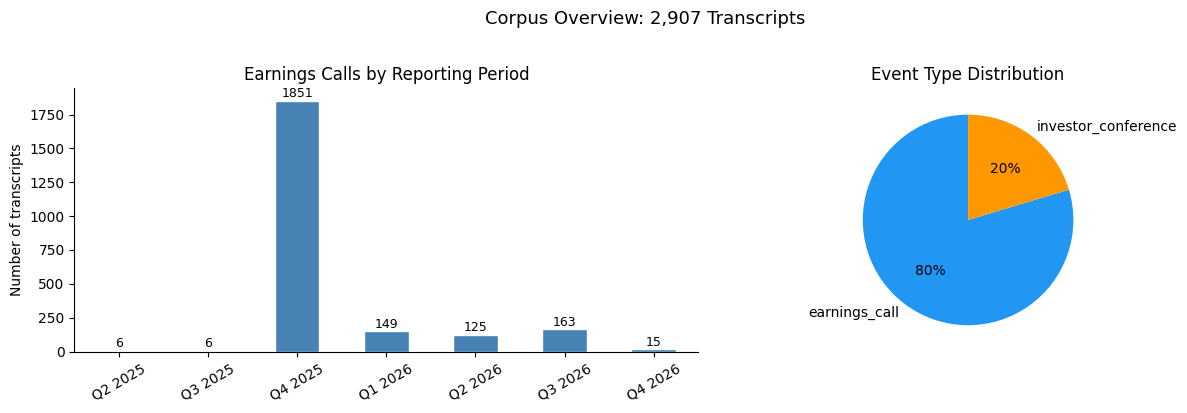

Q4 2025 dominates because the scraper ran during the Feb 2026 earnings season.
Non-calendar-FY companies appear as Q1/Q2/Q3 2026.


In [3]:
# --- Corpus composition by reporting period and event type ---
# The primary temporal dimension is the *reporting period* (fiscal quarter reported),
# not the publication month. Most transcripts report Q4 2025 results, but the corpus
# also includes Q1–Q3 2026 calls for companies with non-calendar fiscal years,
# plus ~590 investor conference presentations (no assigned quarter).

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left panel: earnings calls by reporting period
period_order = ['Q2 2025', 'Q3 2025', 'Q4 2025', 'Q1 2026', 'Q2 2026', 'Q3 2026', 'Q4 2026']
period_counts = (docs[docs['reporting_period'].notna()]
                 .groupby('reporting_period').size().reindex(period_order).dropna())
period_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Earnings Calls by Reporting Period', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of transcripts')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(period_counts):
    axes[0].text(i, v + 5, str(int(v)), ha='center', va='bottom', fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# Right panel: event type breakdown
event_counts = docs['event_type'].fillna('unknown').value_counts()
axes[1].pie(event_counts, labels=event_counts.index, autopct='%1.0f%%',
            colors=['#2196F3', '#FF9800'], startangle=90)
axes[1].set_title('Event Type Distribution', fontsize=12)

fig.suptitle(f'Corpus Overview: {len(docs):,} Transcripts', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/00_corpus_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q4 2025 dominates because the scraper ran during the Feb 2026 earnings season.")
print("Non-calendar-FY companies appear as Q1/Q2/Q3 2026.")

In [4]:
# --- Quarter distribution ---
# Most transcripts are Q4 2025 earnings, with some Q3 2025 and a few Q1/Q2

quarter_counts = docs.groupby(['call_year', 'quarter']).size().reset_index(name='n')
print("Documents by year and quarter:")
print(quarter_counts.to_string(index=False))

Documents by year and quarter:
 call_year quarter    n
    2025.0      Q2    6
    2025.0      Q3    6
    2025.0      Q4 1851
    2026.0      Q1  149
    2026.0      Q2  125
    2026.0      Q3  163
    2026.0      Q4   15


## 2. Text Preprocessing

LDA operates on a **bag-of-words** representation — word order is discarded, and each document becomes a frequency vector over a shared vocabulary. Good preprocessing is therefore critical to topic quality.

We apply the following pipeline:
1. **Lowercase** and remove punctuation/numbers
2. **Tokenize** (split into words)
3. **Remove stopwords** — standard English + a custom earnings-call stoplist capturing boilerplate phrases (*thank you for joining, forward-looking statements*, etc.)
4. **Lemmatize** — reduce inflected forms to their base form (*growing → grow*, *revenues → revenue*)
5. **Filter by length** — keep tokens of 3+ characters
6. **Remove rare and very common tokens** — tokens appearing in fewer than 5 documents or more than 80% of documents add noise

In [5]:
# --- Custom stopwords for earnings call boilerplate ---
# These are domain-specific words that appear in nearly every transcript
# but carry no discriminative topical information.

EARNINGS_STOPWORDS = {
    # Conversational fillers common in spoken transcripts
    'yeah', 'yes', 'okay', 'right', 'sure', 'well', 'actually', 'really',
    'think', 'know', 'going', 'going', 'lot', 'kind', 'thing', 'things',
    'say', 'said', 'look', 'looking', 'come', 'coming', 'good', 'great',
    'thank', 'thanks', 'question', 'answer',
    # Generic financial jargon appearing in every call
    'quarter', 'year', 'fiscal', 'full', 'first', 'second', 'third', 'fourth',
    'q1', 'q2', 'q3', 'q4', 'fy', 'fy25', 'fy26',
    'company', 'business', 'team', 'call', 'conference',
    'result', 'results', 'report', 'reported', 'period',
    'basis', 'point', 'per', 'share', 'million', 'billion',
    'next', 'last', 'prior', 'current', 'previous',
    'one', 'two', 'three', 'four', 'five', 'number',
    # Call protocol boilerplate
    'forward', 'looking', 'statement', 'statements', 'sec', 'filing',
    'caution', 'risk', 'risks', 'actual', 'differ', 'materially',
    'operator', 'line', 'open', 'proceed', 'queue',
}

# Combine with standard English stopwords
STOP_WORDS = set(stopwords.words('english')) | EARNINGS_STOPWORDS

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    """Clean and tokenize a single document."""
    if not isinstance(text, str) or len(text) < 50:
        return []
    # Lowercase and remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    # Tokenize
    tokens = word_tokenize(text)
    # Filter: length >= 3, not a stopword, lemmatize
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if len(t) >= 3 and t not in STOP_WORDS and t.isalpha()
    ]
    return tokens

# Run preprocessing (this takes ~1-2 minutes on 2,900 documents)
print("Preprocessing documents...")
tokenized = [preprocess(text) for text in docs['full_text']]

# Show a preprocessing example
idx = 10
print(f"\nExample — {docs.iloc[idx]['company_name']}")
print(f"  Raw (first 200 chars): {docs.iloc[idx]['full_text'][:200]}")
print(f"  Tokens (first 20):     {tokenized[idx][:20]}")
print(f"\nToken count stats after preprocessing:")
token_lengths = [len(t) for t in tokenized]
print(f"  Mean tokens/doc:   {np.mean(token_lengths):.0f}")
print(f"  Median tokens/doc: {np.median(token_lengths):.0f}")
print(f"  Docs with < 50 tokens: {sum(l < 50 for l in token_lengths)}")

Preprocessing documents...



Example — Emerging Growth Virtual Conference
  Raw (first 200 chars): I’d like to welcome back James B. Frakes, CEO and CFO, and Steven LaRosa, Chief Medical Officer of Aethlon Medical. Aethlon is a medical therapeutic company focused on developing products to treat can
  Tokens (first 20):     ['like', 'welcome', 'back', 'james', 'frakes', 'ceo', 'cfo', 'steven', 'larosa', 'chief', 'medical', 'officer', 'aethlon', 'medical', 'aethlon', 'medical', 'therapeutic', 'focused', 'developing', 'product']

Token count stats after preprocessing:
  Mean tokens/doc:   1136
  Median tokens/doc: 1148
  Docs with < 50 tokens: 8


In [6]:
# --- Build the gensim dictionary and bag-of-words corpus ---

# Filter out documents that are too short after preprocessing
MIN_TOKENS = 50
valid_idx = [i for i, t in enumerate(tokenized) if len(t) >= MIN_TOKENS]
tokenized_clean = [tokenized[i] for i in valid_idx]
docs_clean = docs.iloc[valid_idx].reset_index(drop=True)

print(f"Documents retained (≥{MIN_TOKENS} tokens): {len(docs_clean):,}")

# Build dictionary: maps each unique token to an integer ID
dictionary = corpora.Dictionary(tokenized_clean)
print(f"Vocabulary before filtering: {len(dictionary):,} tokens")

# Filter extremes: remove tokens in fewer than 5 docs or more than 80% of docs
dictionary.filter_extremes(no_below=5, no_above=0.80)
print(f"Vocabulary after filtering:  {len(dictionary):,} tokens")

# Convert to bag-of-words representation
bow_corpus = [dictionary.doc2bow(doc) for doc in tokenized_clean]
print(f"Corpus ready: {len(bow_corpus):,} documents")

Documents retained (≥50 tokens): 2,899


Vocabulary before filtering: 52,176 tokens
Vocabulary after filtering:  13,221 tokens


Corpus ready: 2,899 documents


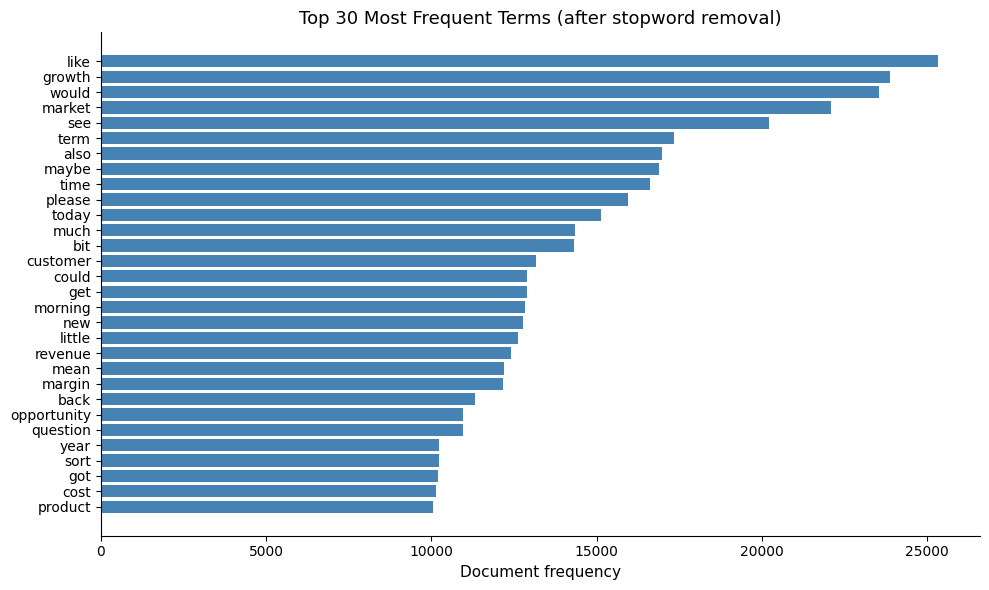

In [7]:
# --- Most frequent terms in the full corpus (word frequency profile) ---
# This gives a first intuition about the vocabulary before topic modeling.

from collections import Counter

all_tokens = [tok for doc in tokenized_clean for tok in doc]
top_terms = Counter(all_tokens).most_common(30)

terms_df = pd.DataFrame(top_terms, columns=['term', 'count'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(terms_df['term'][::-1], terms_df['count'][::-1], color='steelblue')
ax.set_title('Top 30 Most Frequent Terms (after stopword removal)', fontsize=13)
ax.set_xlabel('Document frequency', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/01_top_terms_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. LDA Topic Modeling

### 3a. Selecting the Number of Topics (K)

LDA requires specifying K (number of topics) in advance. We use **topic coherence** (c_v metric) to guide this choice: coherence measures how semantically similar the top words of a topic are, using pointwise mutual information over a reference corpus. Higher coherence = more interpretable topics.

We evaluate K ∈ {5, 8, 10, 12, 15, 18, 20} on a stratified sample of the corpus.

In [8]:
# --- Coherence scoring over a range of K values ---
# We use a sample for speed; the full corpus is used for the final model.

# Use up to 1500 docs for K selection
np.random.seed(42)
sample_size = min(1500, len(bow_corpus))
sample_idx = np.random.choice(len(bow_corpus), sample_size, replace=False)
sample_bow  = [bow_corpus[i] for i in sample_idx]
sample_tok  = [tokenized_clean[i] for i in sample_idx]

K_values = [5, 8, 10, 12, 15, 18, 20]
coherence_scores = []

print("Computing coherence for K =", K_values)
for k in K_values:
    lda_tmp = models.LdaModel(
        corpus=sample_bow,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,
        alpha='auto'
    )
    cm = CoherenceModel(model=lda_tmp, texts=sample_tok,
                        dictionary=dictionary, coherence='c_v')
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"  K={k:2d}  coherence={score:.4f}")

Computing coherence for K = [5, 8, 10, 12, 15, 18, 20]


  K= 5  coherence=0.2589


  K= 8  coherence=0.2687


  K=10  coherence=0.2623


  K=12  coherence=0.2687


  K=15  coherence=0.2631


  K=18  coherence=0.2736


  K=20  coherence=0.2678


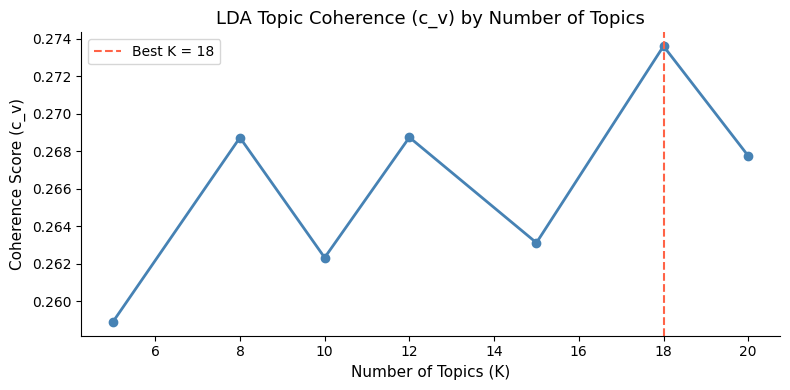

Selected K = 18 based on peak coherence


In [9]:
# --- Plot coherence curve ---

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_values, coherence_scores, marker='o', linewidth=2, color='steelblue')
best_k = K_values[np.argmax(coherence_scores)]
ax.axvline(best_k, linestyle='--', color='tomato', label=f'Best K = {best_k}')
ax.set_title('LDA Topic Coherence (c_v) by Number of Topics', fontsize=13)
ax.set_xlabel('Number of Topics (K)', fontsize=11)
ax.set_ylabel('Coherence Score (c_v)', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/02_coherence_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Selected K = {best_k} based on peak coherence")

### 3b. Fitting the Final LDA Model

We fit the final model on the full corpus using the K that maximized coherence. We use `alpha='auto'` to let the model learn asymmetric topic priors from the data (some topics may be more prevalent than others).

In [10]:
# --- Fit final LDA model on full corpus ---

# Allow manual override: if the coherence peak seems noisy,
# you can set K manually here.
K_FINAL = best_k  # or set manually, e.g. K_FINAL = 15

print(f"Fitting LDA with K={K_FINAL} on {len(bow_corpus):,} documents...")

lda_model = models.LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=K_FINAL,
    random_state=42,
    passes=15,          # more passes = better convergence
    alpha='auto',       # learn asymmetric topic prior
    eta='auto',         # learn asymmetric word prior
    minimum_probability=0.0  # keep all topics in output
)

# Final coherence on full corpus
cm_final = CoherenceModel(model=lda_model, texts=tokenized_clean,
                           dictionary=dictionary, coherence='c_v')
print(f"Final model coherence (c_v): {cm_final.get_coherence():.4f}")

Fitting LDA with K=18 on 2,899 documents...


Final model coherence (c_v): 0.3693


## 4. Topic Exploration

Each topic is a probability distribution over the vocabulary. We examine the top terms per topic and manually assign interpretive labels — this labeling step requires human judgment and domain knowledge.

In [11]:
# --- Print top 15 terms per topic ---

N_TOP_WORDS = 15

print(f"Top {N_TOP_WORDS} terms per topic:\n")
for i in range(K_FINAL):
    terms = lda_model.show_topic(i, topn=N_TOP_WORDS)
    term_str = ', '.join([f"{w}({p:.3f})" for w, p in terms])
    print(f"Topic {i:2d}: {term_str}")

Top 15 terms per topic:

Topic  0: customer(0.011), revenue(0.008), please(0.006), product(0.005), seeing(0.005), come(0.005), opportunity(0.005), platform(0.005), taking(0.005), guy(0.004), brand(0.004), ahead(0.004), way(0.004), margin(0.004), across(0.004)
Topic  1: customer(0.011), got(0.009), gon(0.009), hmm(0.008), mean(0.008), way(0.007), people(0.007), data(0.006), make(0.006), talk(0.006), want(0.006), need(0.006), power(0.005), center(0.005), technology(0.005)
Topic  2: fiber(0.016), network(0.012), revenue(0.010), mobile(0.008), customer(0.008), arpu(0.007), cost(0.007), det(0.006), service(0.006), churn(0.005), spectrum(0.005), capex(0.005), broadband(0.005), subscriber(0.005), wireless(0.005)
Topic  3: revenue(0.011), margin(0.010), opportunity(0.010), customer(0.008), got(0.007), gon(0.006), program(0.006), sort(0.005), guy(0.005), backlog(0.005), cash(0.005), talk(0.005), defense(0.004), mean(0.004), service(0.004)
Topic  4: rate(0.007), portfolio(0.007), asset(0.007), o

In [12]:
# --- Human-assigned topic labels ---
# Labels are assigned by reading the top terms (cell above) and the
# most representative documents (see data/top_docs_per_topic.csv after export).
# Update this dictionary to reflect the model's actual output.

TOPIC_LABELS = {
    0:  "Digital Media & Advertising",
    1:  "Investor Conference (General)",
    2:  "Nordic / European Small Caps",
    3:  "Aerospace, Defense & Industrials",
    4:  "Real Estate & REITs",
    5:  "Financial Services Conference",
    6:  "Mining, Metals & Materials",
    7:  "Oil, Gas & Energy",
    8:  "Industrial Conference (Mixed)",
    9:  "Transport & Logistics",
    10: "Insurance & Specialty Finance",
    11: "Healthcare Conference",
    12: "Biotechnology & Drug R&D",
    13: "Australian & Pacific Markets",
    14: "Energy Infrastructure & Utilities",
    15: "Nordic Markets (Conf.)",
    16: "Industrial Manufacturing",
    17: "Semiconductors & Electronics",
}

print("Topic labels:")
for k, v in TOPIC_LABELS.items():
    print(f"  {k:2d}: {v}")

Topic labels:
   0: Digital Media & Advertising
   1: Investor Conference (General)
   2: Nordic / European Small Caps
   3: Aerospace, Defense & Industrials
   4: Real Estate & REITs
   5: Financial Services Conference
   6: Mining, Metals & Materials
   7: Oil, Gas & Energy
   8: Industrial Conference (Mixed)
   9: Transport & Logistics
  10: Insurance & Specialty Finance
  11: Healthcare Conference
  12: Biotechnology & Drug R&D
  13: Australian & Pacific Markets
  14: Energy Infrastructure & Utilities
  15: Nordic Markets (Conf.)
  16: Industrial Manufacturing
  17: Semiconductors & Electronics


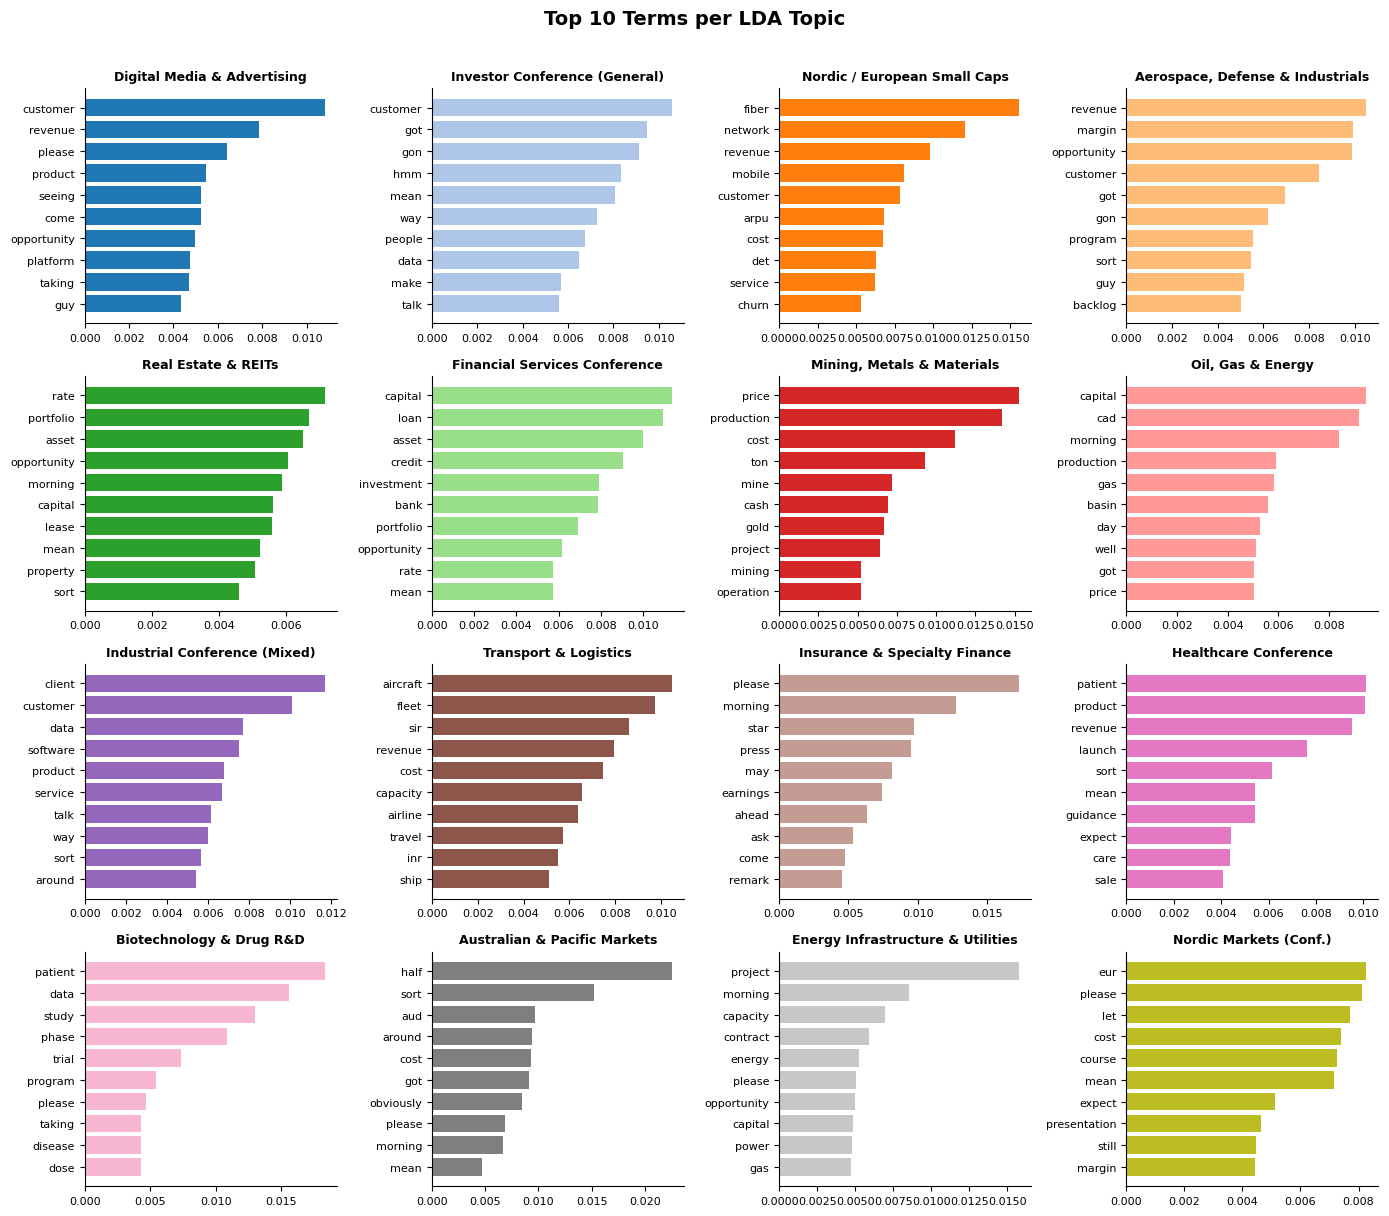

In [13]:
# --- Visualize top terms per topic (bar chart grid) ---

N_SHOW = min(K_FINAL, 16)  # max 16 topics in the grid
ncols = 4
nrows = int(np.ceil(N_SHOW / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i in range(N_SHOW):
    terms = lda_model.show_topic(i, topn=10)
    words = [t[0] for t in terms]
    probs = [t[1] for t in terms]
    axes[i].barh(words[::-1], probs[::-1], color=plt.cm.tab20(i / K_FINAL))
    axes[i].set_title(TOPIC_LABELS[i], fontsize=9, fontweight='bold')
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].tick_params(labelsize=8)

# Hide unused subplots
for j in range(N_SHOW, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 10 Terms per LDA Topic', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_topic_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Document-Topic Distributions

For each document, LDA estimates a distribution over K topics (the γ matrix). We extract this matrix and combine it with the corpus metadata (date, company, etc.) for export to R, where temporal and role-based visualizations will be produced.

In [14]:
# --- Extract document-topic distribution matrix (gamma) ---

print("Extracting document-topic distributions...")
gamma_rows = []
for i, bow_doc in enumerate(bow_corpus):
    topic_dist = dict(lda_model.get_document_topics(bow_doc, minimum_probability=0.0))
    row = {f"topic_{k}": topic_dist.get(k, 0.0) for k in range(K_FINAL)}
    gamma_rows.append(row)

gamma_df = pd.DataFrame(gamma_rows)

# Attach metadata — include temporal fields for R visualization
meta_cols = ['slug', 'url', 'company_name', 'ticker', 'quarter',
             'call_year', 'call_date', 'call_month', 'call_week',
             'reporting_period', 'event_type', 'n_words',
             'n_speaker_turns', 'n_exec_turns', 'n_analyst_turns']
# Only use columns that exist (robustness for older CSV versions)
meta_cols = [c for c in meta_cols if c in docs_clean.columns]
result_df = pd.concat([docs_clean[meta_cols].reset_index(drop=True), gamma_df], axis=1)

# Add dominant topic and its probability for each document
topic_cols_list = [f"topic_{k}" for k in range(K_FINAL)]
result_df['dominant_topic'] = gamma_df[topic_cols_list].idxmax(axis=1).str.replace('topic_', '').astype(int)
result_df['dominant_prob']  = gamma_df[topic_cols_list].max(axis=1)
result_df['dominant_label'] = result_df['dominant_topic'].map(TOPIC_LABELS)

print(f"Gamma matrix shape: {gamma_df.shape}")
print(f"\nDominant topic distribution:")
print(result_df['dominant_label'].value_counts().to_string())

Extracting document-topic distributions...


Gamma matrix shape: (2899, 18)

Dominant topic distribution:
dominant_label
Insurance & Specialty Finance        512
Nordic Markets (Conf.)               416
Digital Media & Advertising          346
Industrial Manufacturing             185
Australian & Pacific Markets         170
Energy Infrastructure & Utilities    156
Real Estate & REITs                  156
Financial Services Conference        142
Aerospace, Defense & Industrials     132
Semiconductors & Electronics         131
Biotechnology & Drug R&D             119
Healthcare Conference                100
Investor Conference (General)         82
Industrial Conference (Mixed)         80
Mining, Metals & Materials            71
Oil, Gas & Energy                     48
Nordic / European Small Caps          28
Transport & Logistics                 25


In [15]:
# --- Export document-topic distributions (gamma) ---

result_df.to_csv('data/doc_topic_distributions.csv', index=False)
print(f"Saved data/doc_topic_distributions.csv ({len(result_df):,} rows)")

# --- Export topic-term distributions (beta) ---
# One row per (topic, term) pair with probability

beta_rows = []
for t in range(K_FINAL):
    for word, prob in lda_model.show_topic(t, topn=30):
        beta_rows.append({'topic': t, 'label': TOPIC_LABELS[t],
                          'term': word, 'probability': prob})

beta_df = pd.DataFrame(beta_rows)
beta_df.to_csv('data/topic_terms.csv', index=False)
print(f"Saved data/topic_terms.csv ({len(beta_df)} rows)")

Saved data/doc_topic_distributions.csv (2,899 rows)
Saved data/topic_terms.csv (540 rows)


## 6. Speaker Role Analysis

One of the distinctive features of earnings calls as a genre is their **dialogic structure**: the prepared remarks phase (executives speak) alternates with the Q&A phase (analysts ask questions, executives respond). If our hypothesis is correct, we should observe that executives and analysts mobilize distinct topical vocabularies:
- **Executives** tend to frame performance in terms of strategy, growth, and forward guidance
- **Analysts** tend to probe specific concerns: margins, competitive dynamics, sector-specific risks

We test this by fitting topic distributions separately on the executive-only and analyst-only subsets of the corpus.

In [16]:
# --- Load speaker-level corpus ---

speakers = pd.read_csv('data/corpus_speaker_level.csv')
print(f"Speaker turns: {len(speakers):,}")
print(f"Role distribution:")
print(speakers['role_type'].value_counts().to_string())

Speaker turns: 133,830
Role distribution:
role_type
executive    66001
analyst      40902
other        19526
operator      6456
ir             945


In [17]:
# --- Aggregate text by role type across all transcripts ---
# For topic comparison, we treat all executive speech as one large virtual
# document, and all analyst speech as another — then apply the trained model.

role_texts = {}
for role in ['executive', 'analyst']:
    role_df = speakers[speakers['role_type'] == role]
    # Tokenize individual turns, then flatten to one large token list
    all_toks = []
    for text in role_df['text']:
        all_toks.extend(preprocess(text))
    role_texts[role] = all_toks
    print(f"{role}: {len(role_df):,} turns → {len(all_toks):,} tokens")

executive: 66,001 turns → 2,077,560 tokens


analyst: 40,902 turns → 802,822 tokens


In [18]:
# --- Infer topic distributions for each role ---
# We use the trained LDA model (vocabulary and topic structure are fixed)
# and infer what topic mixture best explains each role's aggregate text.

role_topic_dists = {}
for role, tokens in role_texts.items():
    bow_role = dictionary.doc2bow(tokens)
    dist = lda_model.get_document_topics(bow_role, minimum_probability=0.0)
    role_topic_dists[role] = {k: v for k, v in dist}

# Build comparison DataFrame
role_compare = pd.DataFrame([
    {'role': role,
     'topic': TOPIC_LABELS[t],
     'topic_id': t,
     'proportion': role_topic_dists[role].get(t, 0.0)}
    for role in ['executive', 'analyst']
    for t in range(K_FINAL)
])

role_compare.to_csv('data/role_topic_comparison.csv', index=False)
print("Saved data/role_topic_comparison.csv")

Saved data/role_topic_comparison.csv


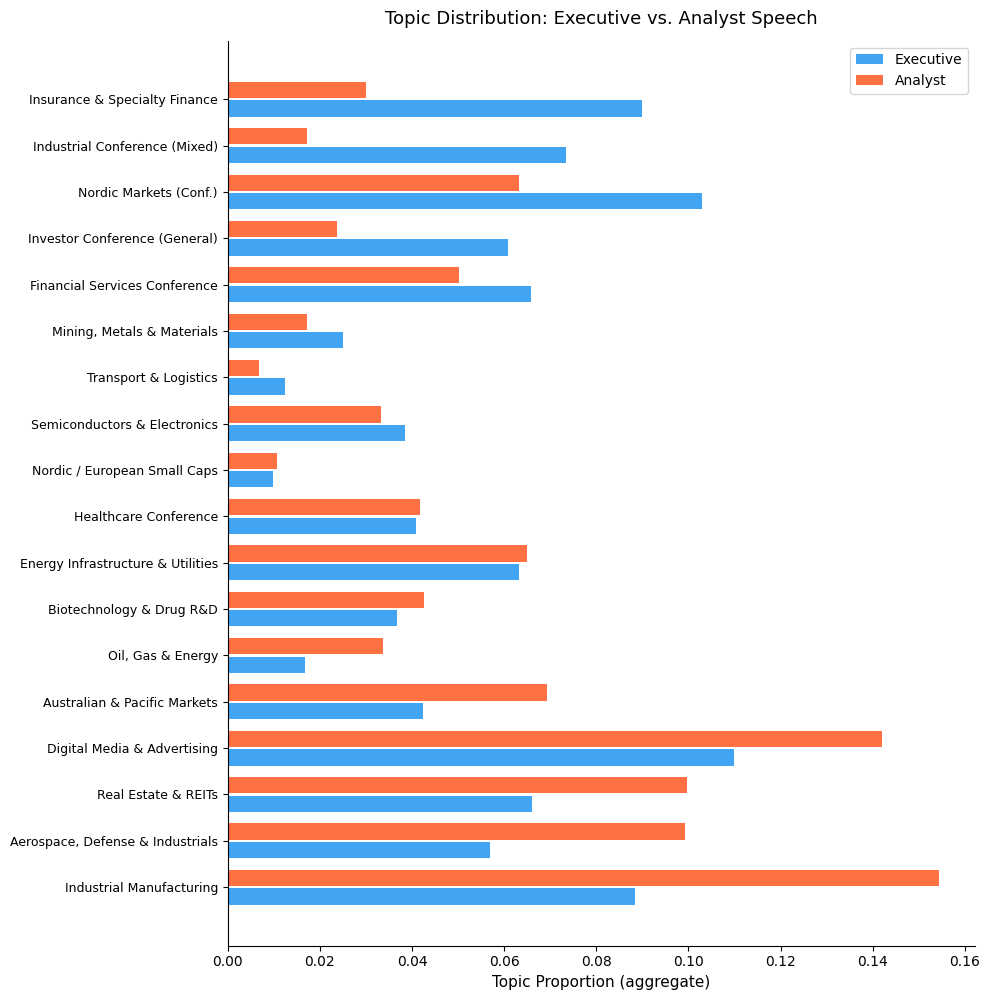


Topics most over-represented in EXECUTIVE speech:
role                           executive  analyst    diff
topic                                                    
Insurance & Specialty Finance     0.0900   0.0301  0.0599
Industrial Conference (Mixed)     0.0734   0.0172  0.0562
Nordic Markets (Conf.)            0.1030   0.0632  0.0398

Topics most over-represented in ANALYST speech:
role                              executive  analyst    diff
topic                                                       
Industrial Manufacturing             0.0885   0.1544 -0.0659
Aerospace, Defense & Industrials     0.0568   0.0992 -0.0423
Real Estate & REITs                  0.0661   0.0997 -0.0337


In [19]:
# --- Visualize executive vs analyst topic profiles ---

pivot = role_compare.pivot(index='topic', columns='role', values='proportion').fillna(0)

# Sort by difference (topics where roles diverge most)
pivot['diff'] = pivot.get('executive', 0) - pivot.get('analyst', 0)
pivot = pivot.sort_values('diff')

fig, ax = plt.subplots(figsize=(10, 0.45 * K_FINAL + 2))

colors = {'executive': '#2196F3', 'analyst': '#FF5722'}
y_pos = np.arange(len(pivot))

if 'executive' in pivot.columns:
    ax.barh(y_pos - 0.2, pivot['executive'], height=0.35,
            label='Executive', color=colors['executive'], alpha=0.85)
if 'analyst' in pivot.columns:
    ax.barh(y_pos + 0.2, pivot['analyst'], height=0.35,
            label='Analyst', color=colors['analyst'], alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xlabel('Topic Proportion (aggregate)', fontsize=11)
ax.set_title('Topic Distribution: Executive vs. Analyst Speech', fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/04_executive_vs_analyst_topics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTopics most over-represented in EXECUTIVE speech:")
print(pivot.nlargest(3, 'diff')[['executive', 'analyst', 'diff']].round(4))
print("\nTopics most over-represented in ANALYST speech:")
print(pivot.nsmallest(3, 'diff')[['executive', 'analyst', 'diff']].round(4))

## Summary and Handoff to R

This notebook has produced:

| File | Description |
|---|---|
| `data/doc_topic_distributions.csv` | γ matrix: one row per transcript, K topic proportions + metadata |
| `data/topic_terms.csv` | β matrix: top 30 terms per topic with probabilities |
| `data/role_topic_comparison.csv` | Topic proportions by speaker role (executive vs. analyst) |

These files are consumed by **`02_visualize_topics.R`**, which produces:
- Monthly topic prevalence plots (temporal evolution)
- Topic heatmaps across companies and time
- Executive vs. analyst topic divergence visualization

### Next steps (Part 2)
Having identified the main topical structure of the corpus, Part 2 will zoom in on a specific topic (e.g., AI/Technology or macroeconomic risk) to conduct a more granular analysis of how language around that topic evolves and which companies are its primary carriers.